Durante este modulo se va a trabajar con este dataset

Del dataset de alzhaimer, predice Diagnosis

Elimina las columnas PatientID y DoctorInCharge

Realiza

1- Regresión logistica

2- De los coeficientes de la logistica, que puedes concluir? ¿cuáles son los mayores factores para tener alzhaimer?

3- Polinomial grado 2

4- Polinomial grado 3

5- KNN (Cross validation para el mejor K)

6- Analisis del discriminante lineal



Para cada modelo:

Histograma
AUC
¿Cuál es el mejor modelo y por qué?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import linear_model
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('alzheimers_disease_data.csv')


In [3]:
df = df.drop(['PatientID', 'DoctorInCharge'], axis=1)

df.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,...,6.045039,0,0,0.014691,0,0,1,1,0,0


# Regresión logística

In [4]:
target = 'Diagnosis'
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)


model = linear_model.LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [5]:
predicciones = model.predict_proba(X_train)

odds = [i[1] / i[0] for i in predicciones]

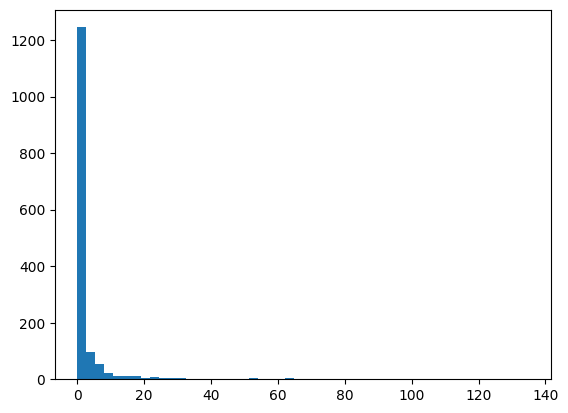

In [6]:
plt.hist(odds, bins=50)
plt.show()

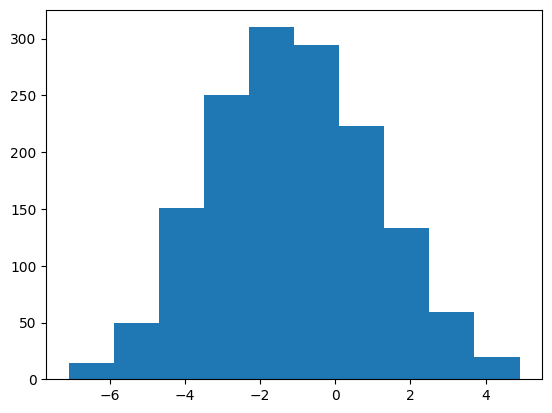

In [7]:
# Calcula y grafica los log odds
log_odds = np.log(odds)

plt.hist(log_odds)
plt.show()

In [8]:
z = model.intercept_ + (model.coef_ * X_train).sum(axis=1)

In [9]:
data1 = pd.DataFrame({
    'z': z,
    'log_odds': log_odds
})
data1.head()

,z,log_odds
971,-0.209415,-0.209415
1985,1.396741,1.396741
268,1.622593,1.622593
481,-3.539966,-3.539966
543,-2.179679,-2.179679


In [10]:
p = 1 / (1 + np.exp(-z))
probabilidades = model.predict_proba(X_train)

data2 = pd.DataFrame({
    'prob_sklearn': [i[1] for i in probabilidades],
    'prob_sigmoid': p
})
data2.head()

,prob_sklearn,prob_sigmoid
971,0.447837,0.447837
1985,0.801666,0.801666
268,0.835152,0.835152
481,0.028196,0.028196
543,0.101590,0.101590


In [11]:
target = 'Diagnosis'

In [12]:
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)


model = linear_model.LogisticRegression()
model.fit(X_train, y_train)

modelo_lineal = model.predict_proba(X_test)

probabilidades_modelo_lineal = [i[1] for i in modelo_lineal]

In [13]:
coeficientes = pd.DataFrame({
    'feature': X_train.keys(),
    'coeficientes': model.coef_[0]
})
coeficientes


,feature,coeficientes
0,Age,0.008823
1,Gender,0.027703
2,Ethnicity,-0.170566
3,EducationLevel,-0.025131
4,BMI,0.029062
5,Smoking,-0.082403
6,AlcoholConsumption,-0.017585
7,PhysicalActivity,0.020185
8,DietQuality,0.023447
9,SleepQuality,-0.120661


De los coeficientes de la logistica, que puedes concluir? ¿cuáles son los mayores factores para tener alzhaimer?

Los coeficientes que más influyen para la predicción de si se tiene alzheimer o no son los que tienes un valor absoluto más alto . La variable memory complaints es la que tiene mayor influencia por ende mayor coeficiente, seguido de la variable que indica problemas de comportamiento  (BehavioralProblems), y Functional Assessement. Si el coeficiente es grande positivo esto significa que en cuanto más incremente esta variable más probabilidad de que el diagnostico sea positivo, y si el coeficiente es grande pero negativo significa lo contrario. En la siguiente celda de código acomodo estos coeficientes de mayor a menor.



In [16]:
coeficientes_ordenados = coeficientes.reindex(coeficientes['coeficientes'].abs().sort_values(ascending=False).index)
coeficientes_ordenados

,feature,coeficientes
24,MemoryComplaints,1.840253
25,BehavioralProblems,1.419258
23,FunctionalAssessment,-0.398846
26,ADL,-0.390196
2,Ethnicity,-0.170566
11,CardiovascularDisease,0.168991
28,Disorientation,-0.162676
31,Forgetfulness,0.149580
30,DifficultyCompletingTasks,0.141200
9,SleepQuality,-0.120661


# Polinomial Grado 2

In [44]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_features", PolynomialFeatures(degree=2)),
    ("model", linear_model.LogisticRegression(penalty='l2'))
])

# Entrenar el modelo
pipeline.fit(X_train, y_train)

# Predecir probabilidades
probabilidades_modelo2 = pipeline.predict_proba(X_test)[:, 1]

roc_auc_score(y_score=probabilidades_modelo2, y_true=y_test)

0.8206481481481481

# Polinomial Grado 3

In [46]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_features", PolynomialFeatures(degree=3)),
    ("model", linear_model.LogisticRegression(penalty='l2'))
])

# Entrenar el modelo
pipeline.fit(X_train, y_train)

# Predecir probabilidades
probabilidades_modelo3 = pipeline.predict_proba(X_test)[:, 1]

roc_auc_score(y_score=probabilidades_modelo3, y_true=y_test)

0.8857716049382717

analisis discriminante lineal

In [52]:
from sklearn import discriminant_analysis


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", discriminant_analysis.LinearDiscriminantAnalysis())
])

pipeline.fit(X_train, y_train)

probabilidades_discriminante_lineal = pipeline.predict_proba(X_test)[:, 1]

roc_auc_score(y_score=probabilidades_discriminante_lineal, y_true=y_test)

0.911090534979424

In [24]:
calibracion = pd.DataFrame({
    'real': y_test,
    'modelo_lineal': probabilidades_modelo_lineal,
    'modelo_cuadratico': probabilidades_modelo2,
    'modelo_cubico': probabilidades_modelo3,
    'modelo_discriminante_lineal': probabilidades_discriminante_lineal,

})

In [25]:
# Bins
bins = 5
calibracion['bins_lineal'] = pd.qcut(calibracion['modelo_lineal'], q=bins, labels=False) + 1
calibracion['bins_cuadratico'] = pd.qcut(calibracion['modelo_cuadratico'],q=bins, labels=False) + 1
calibracion['bins_cubico'] = pd.qcut(calibracion['modelo_cubico'],q=bins, labels=False) + 1
calibracion['bins_discriminante_lineal'] = pd.qcut(calibracion['modelo_discriminante_lineal'], q=bins, labels=False) + 1

# Agrupaciones
grouped_lineal = calibracion.groupby('bins_lineal').mean()
grouped_cuadratico = calibracion.groupby('bins_cuadratico').mean()
grouped_cubico = calibracion.groupby('bins_cubico').mean()
grouped_discriminante_lineal = calibracion.groupby('bins_discriminante_lineal').mean()


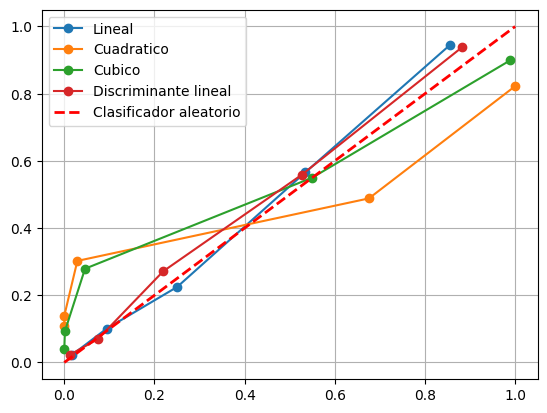

In [26]:
## Grafico de modelos
plt.plot(grouped_lineal.modelo_lineal, grouped_lineal.real, marker="o", label="Lineal")
plt.plot(grouped_cuadratico.modelo_cuadratico, grouped_cuadratico.real, marker="o", label="Cuadratico")
plt.plot(grouped_cubico.modelo_cubico, grouped_cubico.real, marker="o", label="Cubico")
plt.plot(grouped_discriminante_lineal.modelo_discriminante_lineal, grouped_discriminante_lineal.real, marker="o", label="Discriminante lineal")
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.legend()
plt.grid()

In [27]:
from sklearn.metrics import log_loss, accuracy_score

In [28]:
mod1 = log_loss(y_pred=calibracion.modelo_lineal, y_true=calibracion.real)
mod2 = log_loss(y_pred=calibracion.modelo_cuadratico, y_true=calibracion.real)
mod3 = log_loss(y_pred=calibracion.modelo_cubico, y_true=calibracion.real)
mod4 = log_loss(y_pred=calibracion.modelo_discriminante_lineal, y_true=calibracion.real)

print(mod1, mod2, mod3, mod4)

0.385771779273008 1.433400201481132 0.6761839405582923 0.3673222817084052


In [29]:
real1 = calibracion.query("real == 1")
real0 = calibracion.query("real == 0")

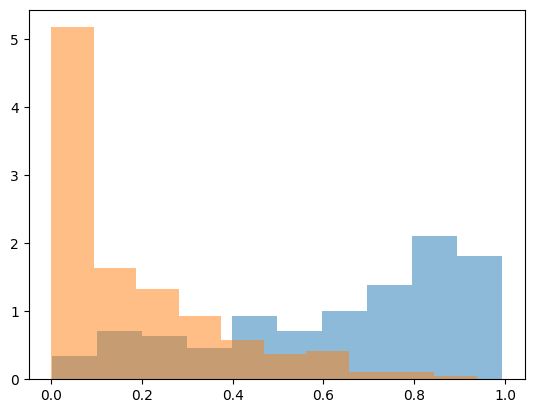

In [31]:
plt.hist(calibracion.modelo_lineal[calibracion.real==1], density=True, alpha=0.5, bins=10)
plt.hist(calibracion.modelo_lineal[calibracion.real==0], density=True, alpha=0.5, bins=10)
plt.show()

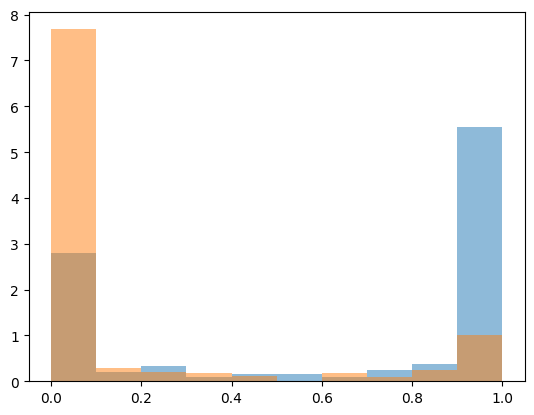

In [33]:
plt.hist(calibracion.modelo_cuadratico[calibracion.real==1], density=True, alpha=0.5, bins=10)
plt.hist(calibracion.modelo_cuadratico[calibracion.real==0], density=True, alpha=0.5, bins=10)
plt.show()

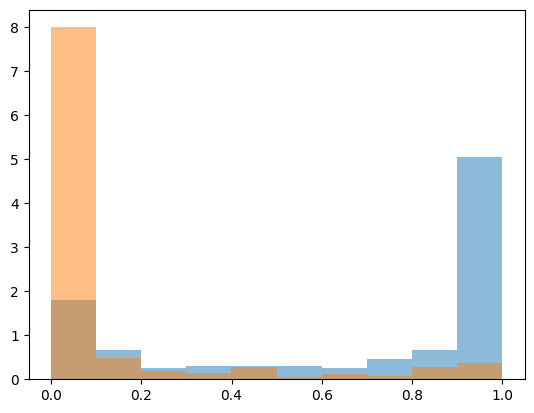

In [34]:
plt.hist(calibracion.modelo_cubico[calibracion.real==1], density=True, alpha=0.5, bins=10)
plt.hist(calibracion.modelo_cubico[calibracion.real==0], density=True, alpha=0.5, bins=10)
plt.show()

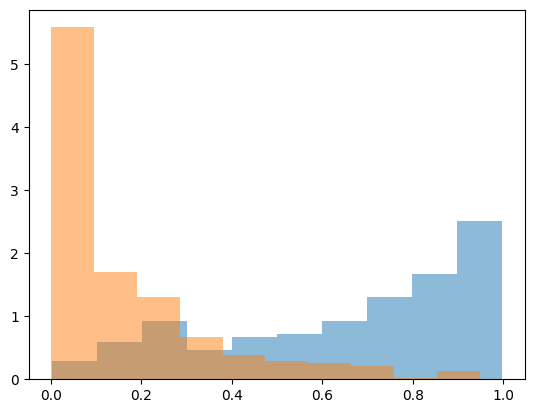

In [35]:
plt.hist(calibracion.modelo_discriminante_lineal[calibracion.real==1], density=True, alpha=0.5, bins=10)
plt.hist(calibracion.modelo_discriminante_lineal[calibracion.real==0], density=True, alpha=0.5, bins=10)
plt.show()

In [37]:
from sklearn.metrics import roc_curve
probabilidades = [i for i in probabilidades]

fpr, tpr, umbrales = roc_curve(y_true=y_test, y_score=probabilidades)

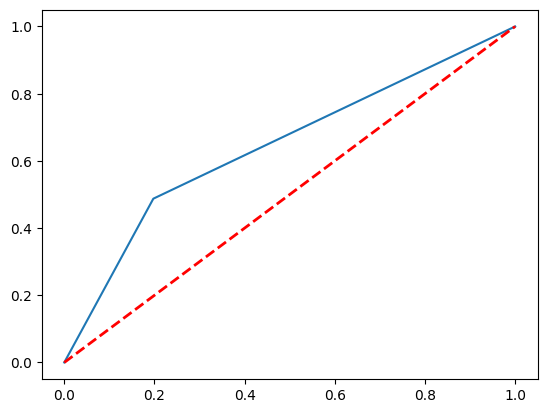

In [39]:
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')

In [41]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_true=y_test, y_score=probabilidades)

0.6449845679012346

In [42]:
from sklearn.neighbors import KNeighborsClassifier
nn = np.linspace(1, 50, 50)
metrics = []
for i in nn:
    pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=int(i))),
    ])

    pipeline.fit(X_train, y_train)

    probabilidades = pipeline.predict_proba(X_test)[:, 1]
    metrics.append(roc_auc_score(y_score=probabilidades, y_true=y_test))


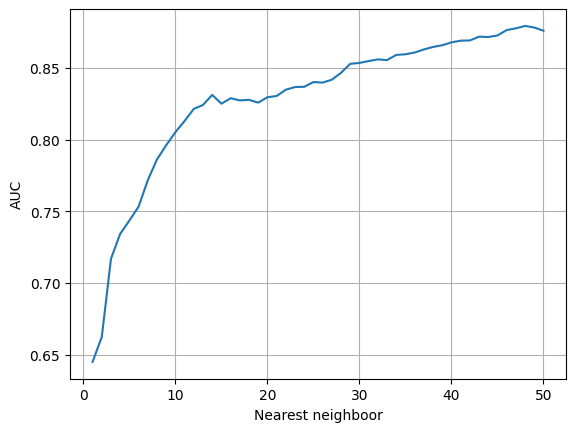

In [43]:
plt.plot(nn, metrics)
plt.xlabel("Nearest neighboor")
plt.ylabel("AUC")
plt.grid()

In [55]:
fpr2, tpr2, umbrales = roc_curve(y_true=y_test, y_score=probabilidades_modelo2)
fpr3, tpr3, umbrales = roc_curve(y_true=y_test, y_score=probabilidades_modelo3)
fpr4, tpr4, umbrales = roc_curve(y_true=y_test, y_score=probabilidades_discriminante_lineal)

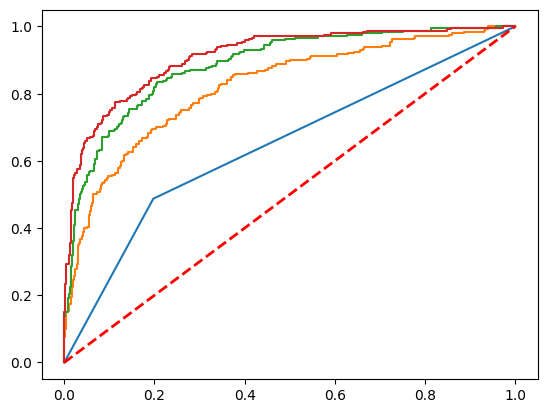

In [56]:
plt.plot(fpr, tpr, label="Lineal")
plt.plot(fpr2, tpr2, label="Cuadratico")
plt.plot(fpr3, tpr3, label="Cubico")
plt.plot(fpr4, tpr4, label="Discriminante lineal")
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')

# KNN

In [49]:
from sklearn.neighbors import KNeighborsClassifier
nn = np.linspace(1, 50, 50)
metrics = []
for i in nn:
    pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=int(i))),
    ])

    pipeline.fit(X_train, y_train)

    probabilidades = pipeline.predict_proba(X_test)[:, 1]
    metrics.append(roc_auc_score(y_score=probabilidades, y_true=y_test))


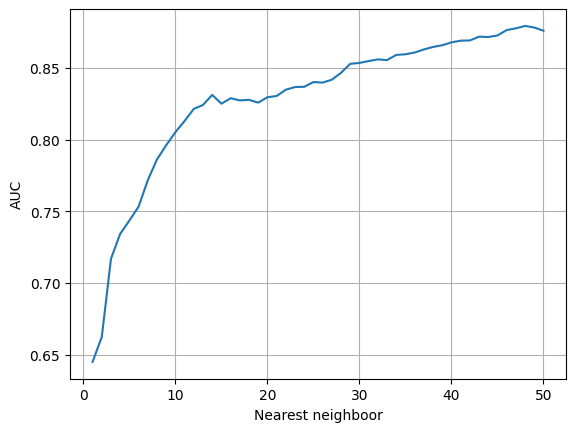

In [50]:
plt.plot(nn, metrics)
plt.xlabel("Nearest neighboor")
plt.ylabel("AUC")
plt.grid()

¿Cuál es el mejor modelo y por qué?


El mejor modelo es el de discriminante lineal. Esto lo podemos confirmar con su resultado de  roc_auc_score. Siendo el más alto (0.91) Esto tambien lo podemos ver en los histogramas. El histograma de este modelo muetsra un área azul mayor a la de los otros modelos lo que significa que hay un  mayor auc score. También, si observamos los valores de calibración podemos ver que el que tiene un menor número es este mismo modelo, lo que indica que es el más preciso (ni tan optimista, ni tan pesimista). Por último podemos observar la gráfica de las AUC, el modelo con un área mayor es el mejor. Este es de nuevo el modelo discriminante lineal.